<a href="https://colab.research.google.com/github/hansi-2000/HR-Project_ML/blob/main/EMP_Attrition_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
## IMPORT LIBRARIES ##

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import the required function for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import train and test split function
from sklearn.model_selection import train_test_split

# Import Classifiers to be used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import packages to calculate performance of the models
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score

# To save the model import pickle
import pickle



In [5]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1LcAPW3c8g7_TJOIU5lV_ySaNgLnbFR3T'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1su6MLRu76QfWwlbbTPrFiz1Yfiav1fuP'
test = pd.read_csv(test_url)

# Check if the data is loaded correctly
print(train.head())
print(test.head())


   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

  Overtime  Distance from Home    Education Level 

In [3]:
emp_data = pd.concat([train, test], ignore_index=True)

emp_data.info()

emp_data.nunique()

emp_data.isnull().sum()
print()

print("Duplicates: ",emp_data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

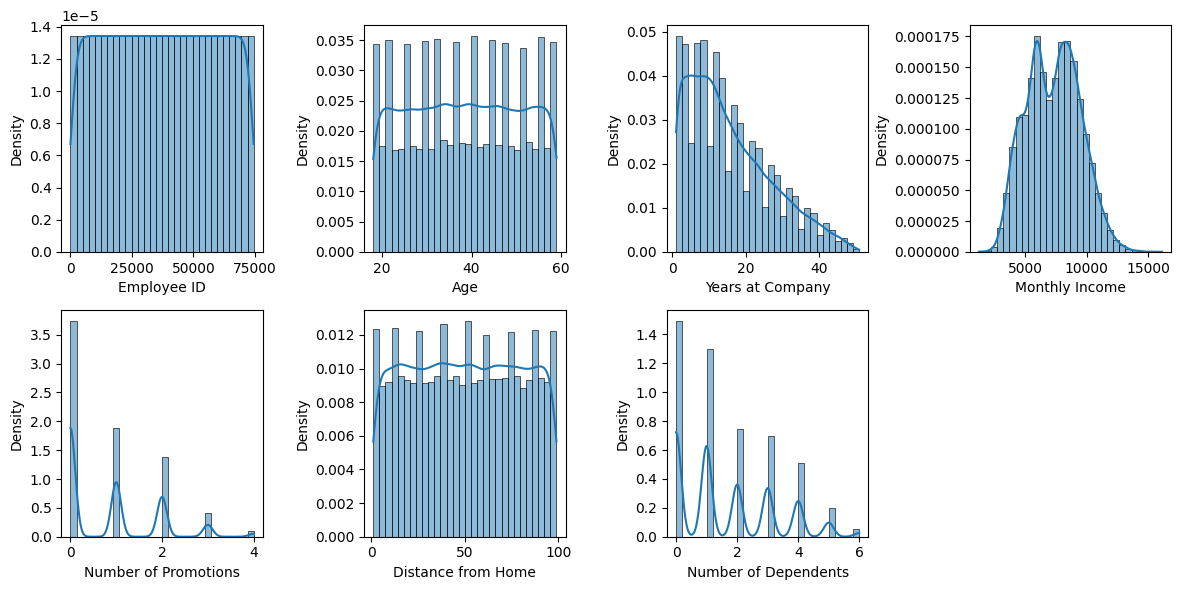

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

emp_eda = emp_data.copy()

# Assuming emp_eda is already defined and contains numeric columns
num_cols_eda = [n for n in emp_eda.columns if emp_eda[n].dtypes != 'O']

# Create a 2x4 grid of subplots (8 subplots total, we'll use 7)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()

# Loop over the first 7 numerical columns and create a histogram for each
for i, col in enumerate(num_cols_eda[:7]):  # Limit to 7 columns
    sns.histplot(emp_eda[col], kde=True, stat='density', bins=30, ax=ax[i])

# Hide the 8th subplot (since we only need 7 plots)
ax[7].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


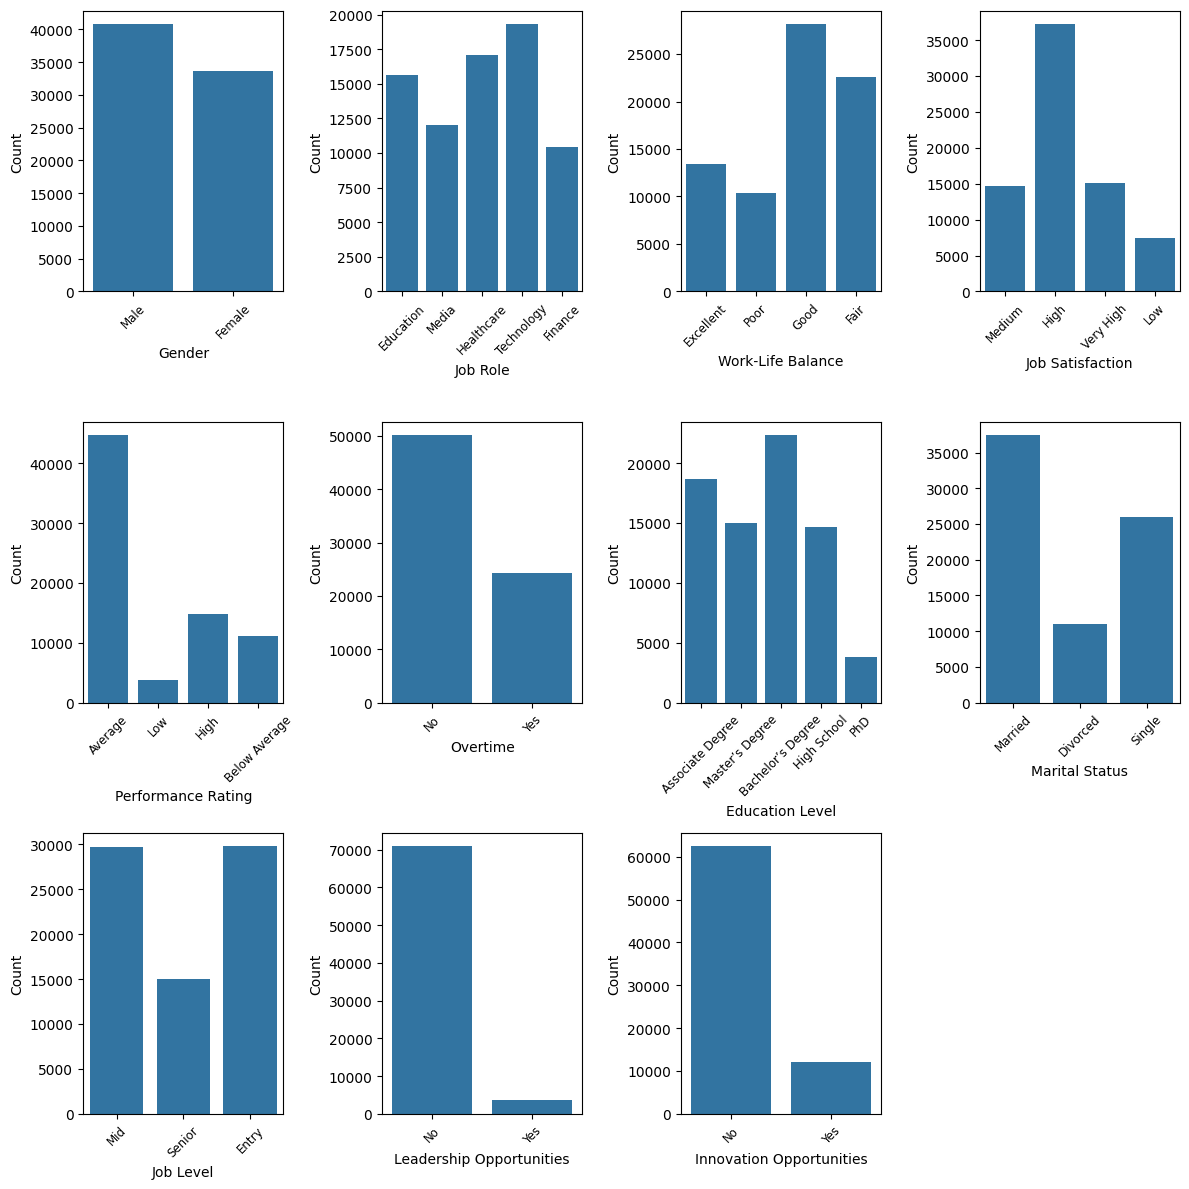

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming emp_eda is already defined and contains categorical columns
cat_cols_eda = [c for c in emp_eda.columns if emp_eda[c].dtypes == 'O']

# Create a 3x4 grid of subplots (12 subplots total)
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop over the first 11 categorical columns and create a countplot for each
for i, col in enumerate(cat_cols_eda[:11]):  # Limit to 11 columns
    sns.countplot(x=col, data=emp_eda, ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].tick_params(axis='x', rotation=45, labelsize=8.5)

# Hide the 12th subplot (since we only need 11 plots)
ax[11].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

emp_data = pd.concat([train, test], ignore_index=True)
emp_data.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Leadership Opportunities,Innovation Opportunities
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,No,No
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,No,No
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,No,No
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,No,No
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,No,No


In [8]:
# emp_data.head()
#print(emp_data.columns)

ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
}

for col, mapping in ordinal_mappings.items():
    emp_data[col] = emp_data[col].map(mapping)


In [9]:
# print("Unique values in Gender column:", emp_data['Gender'].unique())
binary_columns = ['Leadership Opportunities', 'Innovation Opportunities', 'Overtime', 'Gender']

binary_mapping = {'No': 0, 'Yes': 1, 'Male': 0, 'Female': 1}

for col in binary_columns:
    emp_data[col] = emp_data[col].map(binary_mapping)

emp_data.head()

data = emp_data.copy()


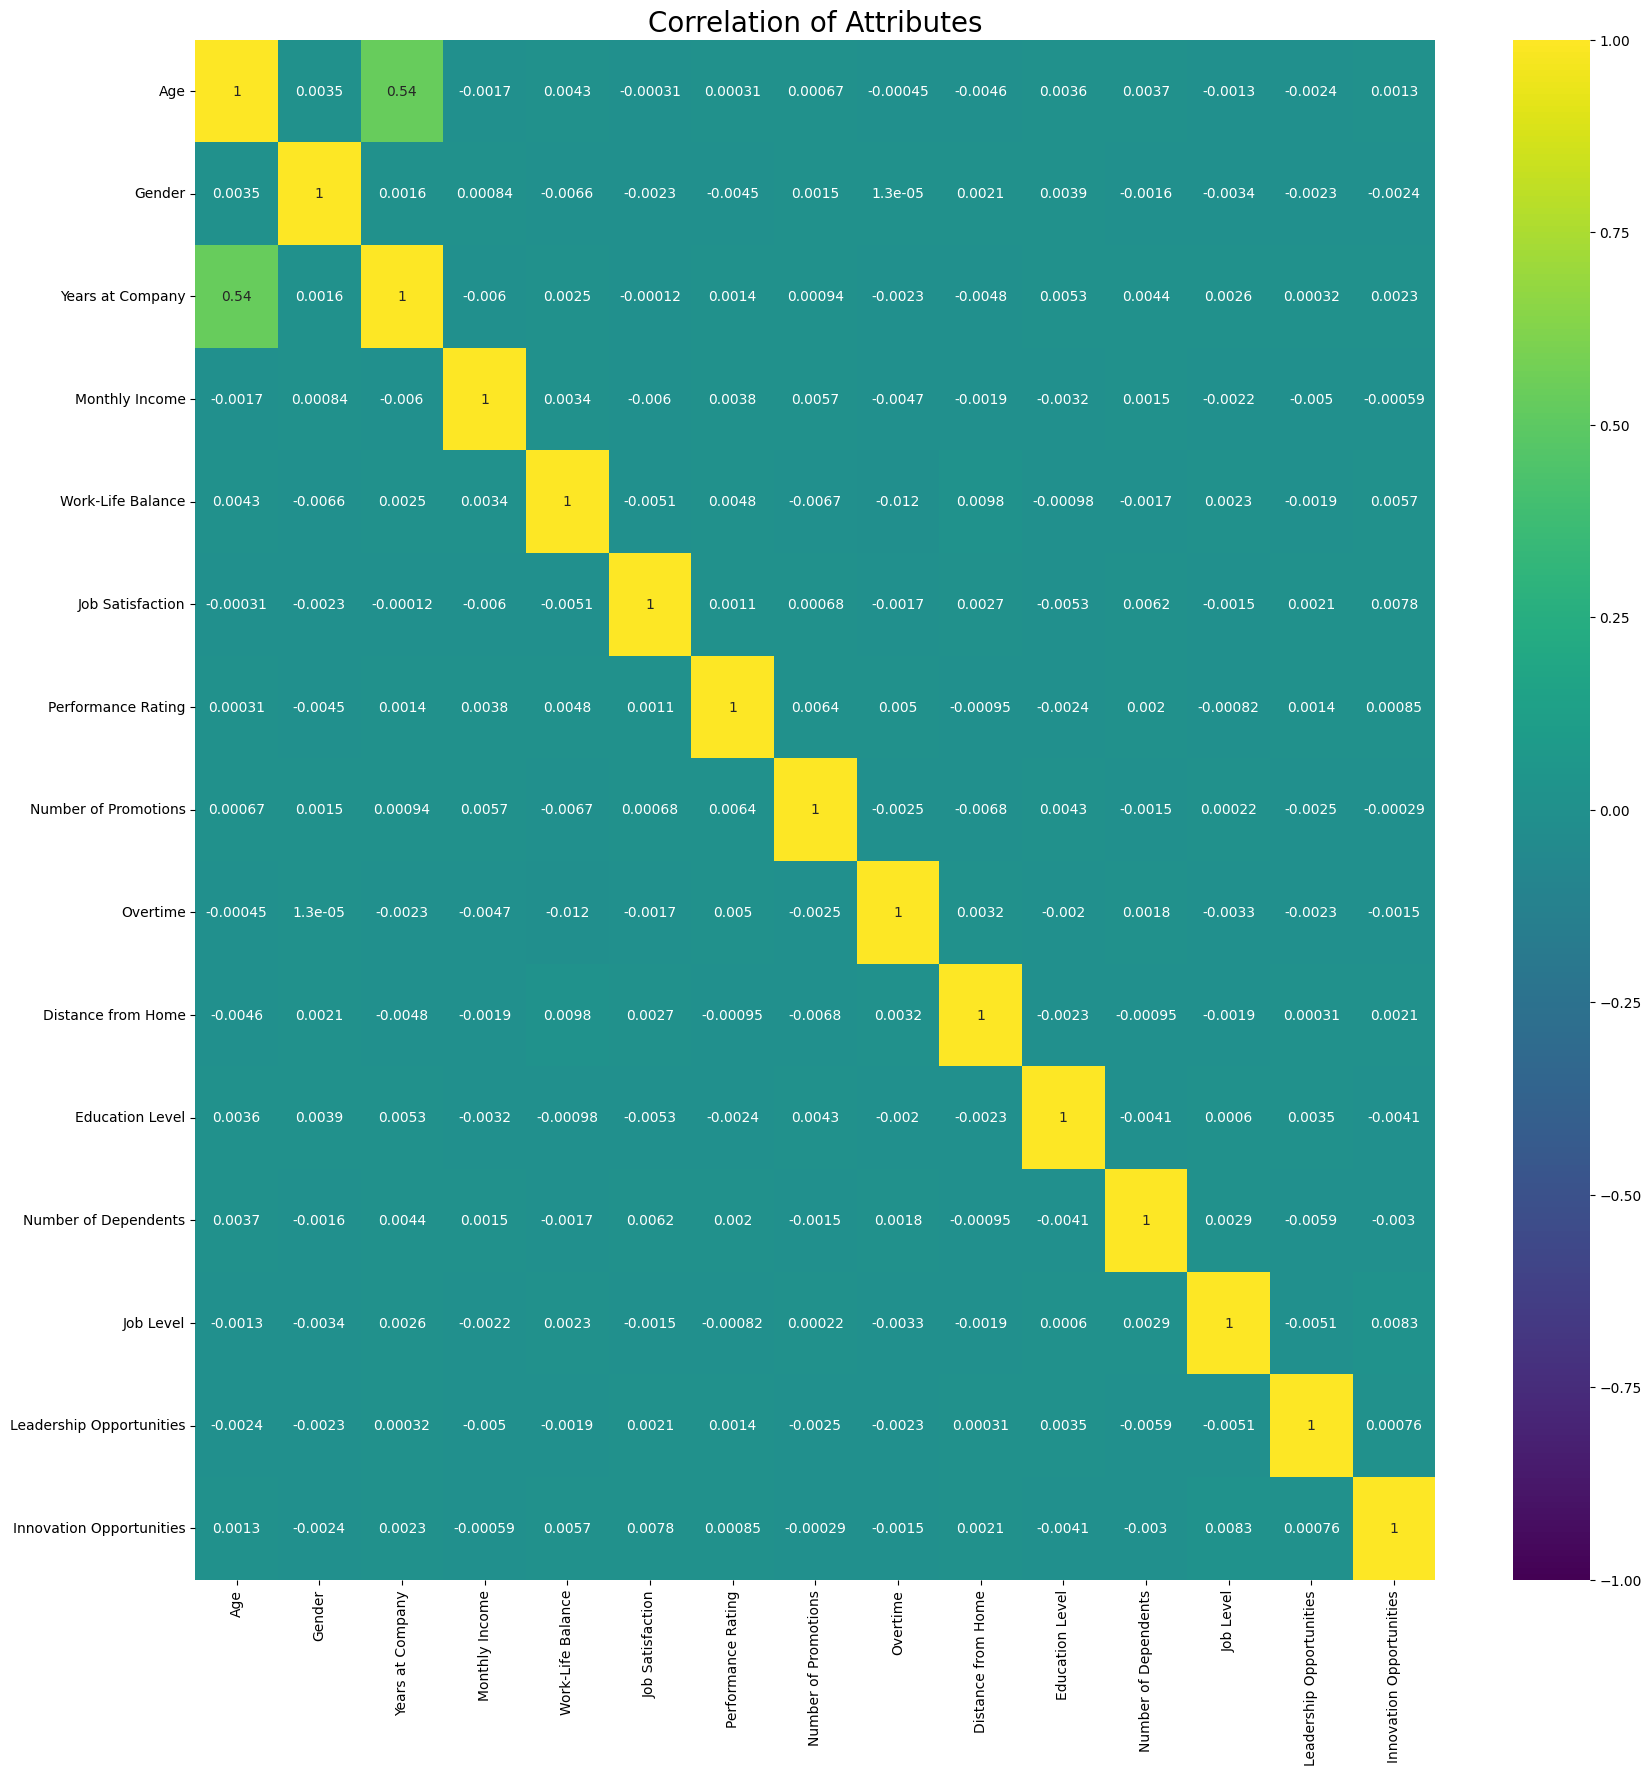

In [10]:
emp_data = emp_data.drop(columns=['Employee ID'])

num_cols = [n for n in emp_data.columns if emp_data[n].dtypes!='O']
colormap = plt.cm.viridis
plt.figure(figsize=(20,20))
plt.title('Correlation of Attributes', size=20)
ax = sns.heatmap(emp_data[num_cols].corr(), cmap=colormap, annot=True, vmin=-1, vmax=1)
plt.show()

In [ ]:
if 'Employee ID' in data.columns:
    data = data.drop(columns=['Employee ID'])
correlation_matrix = data.corr()
print("Correlation Matrix:\n", correlation_matrix)

ValueError: could not convert string to float: 'Education'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create a target variable for attrition (1 for leaving, 0 for staying)
# Replace this with your actual attrition data if available
data['Attrition'] = np.random.randint(0, 2, size=len(data))  # Placeholder for demonstration

# Define features and target
X = data.drop(columns=['Attrition', 'Cluster'])  # Exclude the target and cluster columns
y = data['Attrition']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Get feature coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("Feature Coefficients:\n", coefficients)


NameError: name 'np' is not defined

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import numpy as np


# To find an attrition risk score for each individual employee based on how closely each aligns with high-risk traits,
# we’ll compute a score that indicates their risk of attrition.
# We can achieve this by assigning each employee a score based on their distance from the center of the "high-risk" cluster.

# Cluster the employees based on their features.
# Identify the "high-risk" cluster.
# Calculate the distance of each employee from the high-risk cluster center. Employees closer to this center are at higher risk.
# Normalize these distances to create an individual attrition score for each employee.


# Drop non-informative columns (if any) -----> For example, if 'Employee ID'

#data.head()
#data = data.drop(columns=['Job Role','Marital Status'])

# Step 2: Standardize the data
data = data.drop(columns=['Job Role','Marital Status'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 3: Apply K-Means Clustering
num_clusters = 4  # Adjust this as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
data['Cluster'] = kmeans.fit_predict(data_scaled)
cluster_centers = kmeans.cluster_centers_

# Step 4: Define Feature Weights for Risk Factors
# Assign higher weights to factors you believe are more indicative of attrition
# Adjust weights as per your domain knowledge or business requirements
weights = {
    'JobSatisfaction': 2.0,
    'WorkLifeBalance': 1.5,
    'OverTime': 1.0,
    'Number of Promotions':1.0,
    'DistanceFromHome': 1.0,
    'MonthlyIncome': 1.0
}

# Ensure all weights align with feature columns in standardized data
# Create an array of weights in the same order as the features in cluster_centers
weight_array = np.ones(cluster_centers.shape[1])  # Default to 1 for all features
for i, feature in enumerate(data.columns.drop('Cluster')):
    if feature in weights:
        weight_array[i] = weights[feature]

# Step 5: Calculate Weighted Average for Each Cluster
weighted_centers = cluster_centers * weight_array  # Apply weights
risk_cluster = np.argmax(weighted_centers.mean(axis=1))  # Identify high-risk cluster by weighted average

# Step 6: Calculate Individual Attrition Risk Scores
distances_to_risk_cluster = kmeans.transform(data_scaled)[:, risk_cluster]
data['Attrition_Risk_Score'] = 1 / (distances_to_risk_cluster + 1e-5)

# Normalize the attrition risk score to a range between 0 and 1 for easy interpretation
data['Attrition_Risk_Score'] = (data['Attrition_Risk_Score'] - data['Attrition_Risk_Score'].min()) / \
                               (data['Attrition_Risk_Score'].max() - data['Attrition_Risk_Score'].min())

# Display the results
print("Employee Attrition Risk Scores:\n", data[['Attrition_Risk_Score']].head(74498))


Employee Attrition Risk Scores:
        Attrition_Risk_Score
0                  0.294805
1                  0.128824
2                  0.186911
3                  0.258604
4                  0.262134
...                     ...
74493              0.288618
74494              0.215525
74495              0.238577
74496              0.207803
74497              0.286738

[74498 rows x 1 columns]


Before assigning weights, consider how each feature relates to employee attrition. Here are some general considerations:

Job Satisfaction: Higher job satisfaction generally correlates with lower attrition. A higher weight might be justified if you believe it's a strong predictor.

Work-Life Balance: Similar to job satisfaction, this can greatly influence retention. If your organization values work-life balance, consider a higher weight.

Overtime: Employees who frequently work overtime might be at higher risk of attrition due to burnout. This could justify a higher weight.

Distance From Home: A longer commute may increase the likelihood of attrition. Consider the average commute times of your employees when assigning this weight.

Monthly Income: Higher income can lead to higher job satisfaction, but it can also mean that employees may leave for better-paying opportunities. The weight here can be moderate.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler
import numpy as np
import pandas as pd

# Step 1: Load and preprocess data
data = data.drop(columns=['Job Role', 'Marital Status'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 2: Define parameter grid for KMeans and weights
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random'],
    'max_iter': [100, 200, 300],
    'weights': [
        {'JobSatisfaction': 2.0, 'WorkLifeBalance': 1.5, 'OverTime': 1.0, 'Number of Promotions': 1.0, 'DistanceFromHome': 1.0, 'MonthlyIncome': 1.0},
        {'JobSatisfaction': 1.5, 'WorkLifeBalance': 2.0, 'OverTime': 2.5, 'Number of Promotions': 1.0, 'DistanceFromHome': 1.0, 'MonthlyIncome': 1.0},
        {'JobSatisfaction': 1.0, 'WorkLifeBalance': 1.0, 'OverTime': 1.0, 'Number of Promotions': 1.0, 'DistanceFromHome': 2.0, 'MonthlyIncome': 2.0}
    ]
}

# Step 3: Custom function to apply weights and evaluate clustering
def evaluate_kmeans(n_clusters, init, max_iter, weights):
    # Apply weights to data
    weight_array = np.array([weights.get(col, 1.0) for col in data.columns])
    data_weighted = data_scaled * weight_array

    # Run KMeans with weighted data
    kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
    labels = kmeans.fit_predict(data_weighted)

    # Calculate silhouette score for evaluation
    score = silhouette_score(data_weighted, labels, metric='euclidean')
    return score

# Step 4: Perform randomized search over parameters
n_iter_search = 10  # Set the number of random parameter samples to test
param_list = list(ParameterSampler(param_grid, n_iter=n_iter_search, random_state=42))
best_score = -1
best_params = None

for params in param_list:
    score = evaluate_kmeans(**params)
    if score > best_score:
        best_score = score
        best_params = params

print("Best Score:", best_score)
print("Best Parameters:", best_params)


Best Score: 0.07708478971407393
Best Parameters: {'weights': {'JobSatisfaction': 2.0, 'WorkLifeBalance': 1.5, 'OverTime': 1.0, 'Number of Promotions': 1.0, 'DistanceFromHome': 1.0, 'MonthlyIncome': 1.0}, 'n_clusters': 4, 'max_iter': 200, 'init': 'random'}


In [ ]:
!pip install optuna
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Step 1: Load and preprocess data
#data = data.drop(columns=['Job Role', 'Marital Status'])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 2: Define optimization objective function for Optuna
def kmeans_objective(trial):
    # Sample KMeans parameters
    n_clusters = trial.suggest_int('n_clusters', 2, 6)
    init = trial.suggest_categorical('init', ['k-means++', 'random'])
    max_iter = trial.suggest_int('max_iter', 100, 300)

    # Sample weights for key features
    weights = {
        'JobSatisfaction': trial.suggest_float('JobSatisfaction', 1.0, 3.0),
        'WorkLifeBalance': trial.suggest_float('WorkLifeBalance', 1.0, 3.0),
        'OverTime': trial.suggest_float('OverTime', 1.0, 3.0),
        'Number of Promotions': trial.suggest_float('Number of Promotions', 1.0, 3.0),
        'DistanceFromHome': trial.suggest_float('DistanceFromHome', 1.0, 3.0),
        'MonthlyIncome': trial.suggest_float('MonthlyIncome', 1.0, 3.0)
    }

    # Apply weights to features in scaled data
    weight_array = np.array([weights.get(col, 1.0) for col in data.columns])
    data_weighted = data_scaled * weight_array

    # Run KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, init=init, max_iter=max_iter, random_state=42)
    labels = kmeans.fit_predict(data_weighted)

    # Calculate and return silhouette score
    score = silhouette_score(data_weighted, labels, metric='euclidean')
    return score

# Step 3: Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(kmeans_objective, n_trials=30)  # Increase n_trials as needed for finer tuning

print("Best Trial:", study.best_trial)  # This should output the best trial details if available

# Display best parameters and score
print("Best Score:", study.best_value)
print("Best Parameters:", study.best_params_)


[I 2024-10-31 03:11:12,326] A new study created in memory with name: no-name-3b359d91-1af6-4ba9-97e6-4c8e7bf842c0
[I 2024-10-31 03:12:17,539] Trial 0 finished with value: 0.12883217692694515 and parameters: {'n_clusters': 3, 'init': 'random', 'max_iter': 102, 'JobSatisfaction': 1.9873185317228872, 'WorkLifeBalance': 2.623373746102043, 'OverTime': 2.2504968309277, 'Number of Promotions': 2.8478457503448107, 'DistanceFromHome': 1.8536499480071857, 'MonthlyIncome': 1.6628214094236466}. Best is trial 0 with value: 0.12883217692694515.
[I 2024-10-31 03:13:22,220] Trial 1 finished with value: 0.10791869038065348 and parameters: {'n_clusters': 4, 'init': 'random', 'max_iter': 186, 'JobSatisfaction': 1.8194231985527216, 'WorkLifeBalance': 1.1065448612279998, 'OverTime': 1.4290636074158896, 'Number of Promotions': 2.182014833198658, 'DistanceFromHome': 2.7704788677476806, 'MonthlyIncome': 2.5787513026150144}. Best is trial 0 with value: 0.12883217692694515.
[I 2024-10-31 03:14:27,746] Trial 2 f

In [12]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Assuming `emp_data` is your preprocessed data frame and High_Risk is the synthetic label
processed_df = emp_data.copy()
processed_df = processed_df.drop(columns=['Job Role', 'Marital Status'])

isolation_forest = IsolationForest(n_estimators=100, max_samples=0.8, contamination=0.05, random_state=42)
isolation_forest.fit(processed_df)
processed_df['Attrition_Risk_Score'] = -isolation_forest.decision_function(processed_df)

# Define high-risk threshold (top 5% of scores)
threshold = processed_df['Attrition_Risk_Score'].quantile(0.95)
processed_df['High_Risk'] = processed_df['Attrition_Risk_Score'] > threshold

# Define X and y
X = processed_df.drop(columns=['Attrition_Risk_Score', 'High_Risk'])
y = processed_df['High_Risk'].astype(int)  # Convert to 0 and 1 for classification


# Step 1: Perform SMOTE with higher sampling
smote = SMOTE(sampling_strategy=0.8, random_state=42)  # Increase sampling ratio
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 2: Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Step 3: Define a RandomForestClassifier with class_weight and hyperparameter tuning
# We'll use GridSearchCV to find optimal hyperparameters
param_grid = {
    'n_estimators': [100, 150],  # Increasing the number of estimators
    'min_samples_split': [2, 5, 10],  # Adjust minimum samples required to split
    'min_samples_leaf': [1, 2, 4],  # Minimum samples in each leaf
    'class_weight': ['balanced_subsample']
}

# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)

# Train the model with best parameters
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Step 4: Evaluate the model
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature Importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", feature_importances)


Best Parameters: {'class_weight': 'balanced_subsample', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Accuracy: 0.9049139149092051
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91     21321
           1       0.88      0.91      0.89     16897

    accuracy                           0.90     38218
   macro avg       0.90      0.91      0.90     38218
weighted avg       0.91      0.90      0.91     38218

Feature Importances:
                      Feature  Importance
3             Monthly Income    0.141566
6         Performance Rating    0.116477
9         Distance from Home    0.102892
13  Leadership Opportunities    0.100791
2           Years at Company    0.092996
0                        Age    0.087438
5           Job Satisfaction    0.079415
4          Work-Life Balance    0.059995
11      Number of Dependents    0.046874
10           Education Level    0.040462
7       Number of Promo

we can implement the Random Forest approach using synthetic labels created by the Isolation Forest model. This will allow us to get feature importance values from the Random Forest model to understand each feature's positive or negative impact on the attrition risk.


Step 1: Generate Synthetic Labels Using Isolation Forest

First, we'll run Isolation Forest on the preprocessed dataset to get the Attrition_Risk_Score for each employee.
Define high-risk employees based on a risk threshold (e.g., top 5% highest scores).
Use this high-risk flag as a synthetic label to train the Random Forest model.


Step 2: Train a Random Forest Model Using Synthetic Labels

Train a Random Forest model using the synthetic labels (high-risk vs. low-risk).
Extract the feature importances from the trained Random Forest model.


Step 3: Interpret Feature Importances

Analyze the feature importances to understand which features contribute more to the attrition risk.
Features with higher importance scores are stronger predictors of high attrition risk.